In [1]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
#from torchmetrics.regression import R2Score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

/home/marcos/.pyenv/versions/3.10.13/envs/gnn-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
        "2024-03-01 05:00:00",  # ini train
        "2024-03-17 00:00:00",  # end train (último X antes da validação)
        "2024-03-18 05:00:00",  # ini val (começa logo após o último treino)
        "2024-03-31 00:00:00",  # end val (último X antes do teste)
        "2024-04-01 05:00:00",  # ini test (começa logo após a validação)
        "2024-05-10 00:00:00",  # end test

('2024-05-10 00:00:00',)

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
#plt.style.use('seaborn-whitegrid')
#pd.set_option('display.float_format', '{:.16f}'.format)
warnings.filterwarnings('ignore')

In [4]:
sb = pd.read_parquet("/home/marcos/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


In [5]:
serie = sb["125960550"]

In [6]:
total_points = sb.shape[0]
t = np.arange(total_points)

In [7]:
limite_marco = 31 * 40
limite_abril = limite_marco + (30 * 40)
limite_marco, limite_abril

(1240, 2440)

In [20]:
future_steps = sb.shape[0] - limite_marco
future_steps

2400

In [22]:
sb["125960550"][limite_marco:].shape

(2400,)

In [9]:
input_size = 40  # tamanho da janela de entrada
train_points = limite_marco  # 1 mês
future_steps = future_steps  
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
def create_windows(data, input_size):
    X, y = [], []
    for i in range(len(data) - input_size):
        X.append(data[i:i+input_size])
        y.append(data[i+input_size])
    return np.array(X), np.array(y)

In [11]:

X_train, y_train = create_windows(serie[:train_points], input_size)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

In [12]:
X_train.shape, y_train.shape

(torch.Size([1200, 40]), torch.Size([1200, 1]))

In [13]:
X_train[0]

tensor([ 1.3333,  3.5952,  4.8130,  9.2156, 12.5850, 13.6600, 16.3522, 18.3961,
        18.6461, 18.8128, 20.4735, 21.0290, 20.0290, 19.1838, 20.7529, 18.8653,
        15.9959, 17.3051, 14.6962, 14.3092, 14.1426, 15.5790, 14.0017, 15.8603,
        17.4436, 18.2563, 15.8028, 15.9009, 16.2606, 14.5709, 15.3106, 13.6537,
        14.6138, 13.6735, 13.5902, 11.3843, 10.1083,  7.8789,  7.5456,  4.9324],
       device='cuda:0')

## Model

In [14]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_size).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [15]:
# --- 5. TREINAMENTO
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 10/500, Loss: 129.5245
Epoch 20/500, Loss: 53.0409
Epoch 30/500, Loss: 29.9338
Epoch 40/500, Loss: 23.6585
Epoch 50/500, Loss: 22.1706
Epoch 60/500, Loss: 18.5602
Epoch 70/500, Loss: 16.4895
Epoch 80/500, Loss: 14.2094
Epoch 90/500, Loss: 12.0909
Epoch 100/500, Loss: 10.2461
Epoch 110/500, Loss: 8.7030
Epoch 120/500, Loss: 7.5098
Epoch 130/500, Loss: 6.6461
Epoch 140/500, Loss: 6.0363
Epoch 150/500, Loss: 5.5965
Epoch 160/500, Loss: 5.2591
Epoch 170/500, Loss: 4.9790
Epoch 180/500, Loss: 4.7271
Epoch 190/500, Loss: 4.4828
Epoch 200/500, Loss: 4.2339
Epoch 210/500, Loss: 3.9806
Epoch 220/500, Loss: 3.7349
Epoch 230/500, Loss: 3.4966
Epoch 240/500, Loss: 3.2638
Epoch 250/500, Loss: 3.0532
Epoch 260/500, Loss: 2.8755
Epoch 270/500, Loss: 2.7208
Epoch 280/500, Loss: 2.5877
Epoch 290/500, Loss: 2.4719
Epoch 300/500, Loss: 2.3706
Epoch 310/500, Loss: 2.2811
Epoch 320/500, Loss: 2.2017
Epoch 330/500, Loss: 2.1294
Epoch 340/500, Loss: 2.0623
Epoch 350/500, Loss: 1.9964
Epoch 360/500, Los

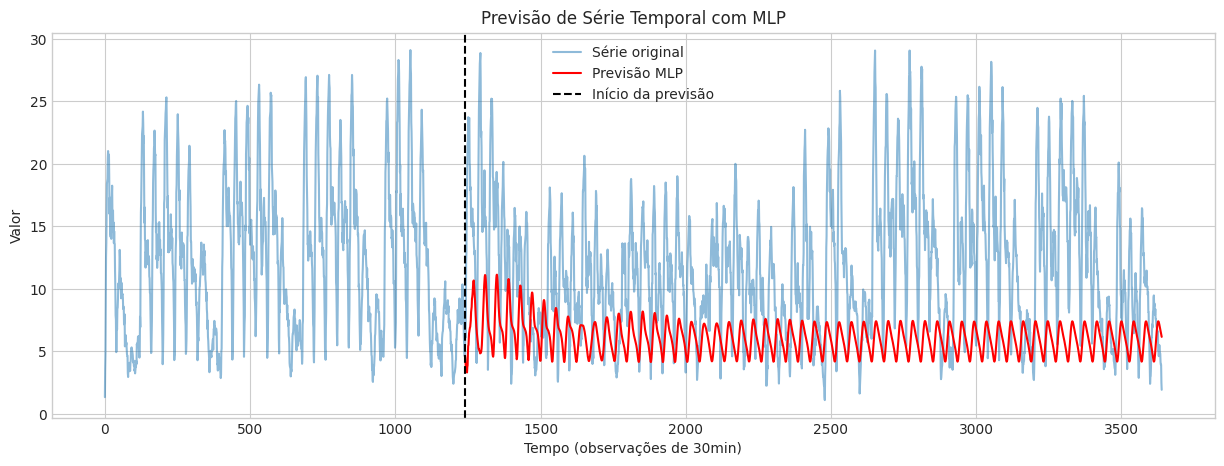

In [17]:
model.eval()
history = list(serie[:train_points])  # Começa com o primeiro mês
predictions = []

for _ in range(future_steps):
    x_input = torch.tensor(history[-input_size:], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x_input).item()
    predictions.append(pred)
    history.append(pred)  # feedback do próprio modelo

# --- 7. PLOT
plt.figure(figsize=(15,5))
plt.plot(t, serie, label="Série original", alpha=0.5)
plt.plot(t[train_points:train_points+future_steps], predictions, label="Previsão MLP", color="r")
plt.axvline(x=train_points, color='k', linestyle='--', label="Início da previsão")
plt.legend()
plt.title("Previsão de Série Temporal com MLP")
plt.xlabel("Tempo (observações de 30min)")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

In [19]:
len(predictions)

2400